# KNN (k-Nearest Neighbors) — Полный разбор

## 1. Введение

Алгоритм k-ближайших соседей (KNN) — это простой, но мощный метод машинного обучения, используемый для:

* классификации
* регрессии

Идея: объект классифицируется на основе классов ближайших к нему объектов.

## 2. Основная идея

1) сначала вычисляется расстояние между тестовым и всеми обучающими образцами;
2) далее из них выбирается k-ближайших образцов (соседей), где число k задаётся заранее;
3) итоговым прогнозом среди выбранных k-ближайших образцов будет мода в случае классификации и среднее арифметическое в случае регрессии;
4) предыдущие шаги повторяются для всех тестовых образцов.

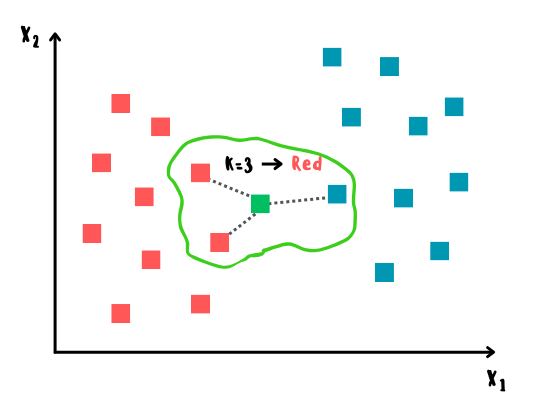

## 3. Метрики расстояния

### Евклидово расстояние
это наиболее простая и общепринятая метрика, которая определяется как длина отрезка между двумя объектами $a$ и $b$ в пространстве с $n$ признаками и вычисляется по формуле:

$$ d = \sqrt{\sum (x_i - y_i)^2} $$

### Манхэттенское расстояние
Манхэттенское расстояние — метрика, которая определяется как сумма модулей разностей координат двух точек в пространстве между двумя объектами $a$ и $b$ с $n$ признаками и вычисляется по формуле:

$$ d = \sum |x_i - y_i| $$

### Косинусное расстояние
метрика, которая определяется как угол между двумя векторами a и b в пространстве с n признаками и вычисляется по формуле:

$$d(a, b) = 1- \frac{\sum_{i=1}^{n}{a_i*b_i}}{\sqrt{\sum_{i=1}^{n}{a_i^2}}\sqrt{\sum_{i=1}^{n}{b_i^2}}}$$

## Важные параметры

* k — число соседей
* метрика расстояния
* веса (равные или по расстоянию)

Малое k → переобучение

Большое k → недообучение

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris, load_diabetes
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [23]:
# Генерация данных
X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [25]:
scaller = StandardScaler()

model = KNeighborsClassifier()

pipe = Pipeline([
    ('scaller', scaller),
    ('model', model)])

# Обучение модели
model = GridSearchCV(
    pipe,
    param_grid={
        'model__n_neighbors': [1, 6, 5, 7, 8, 9, 12, 13, 41],
        
        },
    cv=5,
    scoring='accuracy'
)

model.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__n_neighbors': [1, 6, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and c

In [4]:
model.predict(X_test)

array([2, 0, 2, 0, 0, 2, 0, 1, 2, 2, 1, 2, 1, 0, 1, 0, 1, 2, 0, 0, 0, 2,
       2, 0, 0, 2, 2, 1, 0, 1, 1, 1, 0, 1, 1, 2, 2, 0])

In [10]:
class KNearestNeighbors:
    def __init__(self, n_neighbors=5, regression=False):
        self.n_neighbors = n_neighbors
        self.regression = regression

    def fit(self, X_train, y_train):
        self.X_train, self.y_train = X_train, y_train

    def _euclidean_distances(self, x_test_i):
        return np.sqrt(np.sum((self.X_train - x_test_i) ** 2, axis=1))

    def _make_prediction(self, x_test_i):
        distances = self._euclidean_distances(x_test_i)   # distances to all neighbors
        print(distances)
        k_nearest_indexes = np.argsort(distances)[:self.n_neighbors]
        print(k_nearest_indexes)
        targets = self.y_train[k_nearest_indexes]   # k-nearest neighbors target values
        print(targets)

        return np.mean(targets) if self.regression else np.bincount(targets).argmax()

    def predict(self, X_test):
        return np.array([self._make_prediction(x) for x in X_test])

In [20]:
knn_clf = KNearestNeighbors(n_neighbors=5)
knn_clf.fit(X_train, y_train)
#y_pred = knn_clf._make_prediction(X_test[0])
y_pred = knn_clf.predict(X_test)

accuracy_score(y_pred, y_test)

[5.60357029 5.50454358 1.01488916 5.53985559 1.21243557 2.64386081
 2.78747197 5.40185153 1.90525589 3.02820079 5.5208695  5.56237359
 1.1045361  2.33666429 1.98997487 1.58745079 0.98488578 5.75760367
 5.5883808  1.22065556 3.95600809 2.07364414 1.46628783 5.82666285
 1.43874946 2.24276615 1.02956301 2.12132034 2.84780617 3.81837662
 5.68770604 1.73205081 1.59373775 1.79164729 1.93390796 3.91024296
 1.74642492 0.99498744 2.21359436 5.37215041 2.70185122 5.58211429
 5.82666285 6.1991935  5.5812185  2.04205779 5.51089829 2.10950231
 2.70924344 2.54361947 5.65862174 3.02324329 3.22024844 5.56237359
 6.00499792 6.2401923  2.46170673 2.24944438 0.92736185 3.04959014
 1.13578167 5.86600375 5.46351535 0.54772256 5.65950528 2.49599679
 2.9        1.93907194 1.84661853 5.63737528 5.58032257 5.81377674
 5.70263097 5.61871872 2.63628527 5.75847202 1.5        2.68700577
 1.47648231 1.18321596 3.3        0.43588989 2.03960781 0.678233
 5.91438923 1.22065556 1.63401346 0.55677644 1.69115345 5.612486

0.9736842105263158

In [16]:
X_train[0]

array([4.9, 3.1, 1.5, 0.2])

In [7]:
knn_clf = KNearestNeighbors()
knn_clf.fit(X_train, y_train)
knn_clf_pred_res = knn_clf.predict(X_test)
knn_clf_accuracy = accuracy_score(y_test, knn_clf_pred_res)

print(f'KNN classifier accuracy: {knn_clf_accuracy:}')
print(knn_clf_pred_res)

KNN classifier accuracy: 0.9736842105263158
[2 0 2 0 0 2 0 1 2 2 1 2 1 0 1 0 1 2 0 0 0 2 2 0 0 2 2 1 0 1 1 1 0 1 2 2 2
 0]


In [8]:
X_iris, y_iris = load_iris(return_X_y=True, as_frame=True)
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(X_iris.values, y_iris.values, random_state=0)
print(X_iris, y_iris, sep='\n')

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
0      0
1      0
2      0
3      0
4   

In [9]:
knn_clf = KNearestNeighbors()
knn_clf.fit(X_iris_train, y_iris_train)
knn_clf_pred_res = knn_clf.predict(X_iris_test)
knn_clf_accuracy = accuracy_score(y_iris_test, knn_clf_pred_res)

print(f'KNN classifier accuracy: {knn_clf_accuracy:}')
print(knn_clf_pred_res)

KNN classifier accuracy: 0.9736842105263158
[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]


## Преимущества и недостатки KNN

Преимущества:

- простота в реализации и интерпретации;
- применяется во многих задачах, особенно в рекомендательных системах;
- высокая точность прогнозов при правильном подборе k и метрики расстояния.

Недостатки:

- большое потребление памяти и низкая скорость работы из-за хранения и вычисления расстояний между всеми обучающими и тестовыми образцами (имеется в виду KNN в чистом виде);
- чувствительность к выбросам и шуму, а также к несбалансированным классам в данных;
- при большом количестве признаков может возникнуть проблема совпадения метрической и смысловой близости объектов, что решается с помощью обучения представлений (численное описание объектов).